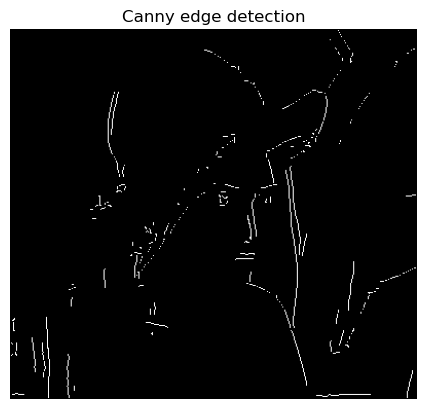

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 实现Canny边缘检测的函数
def canny_edge_detection(image_path, low_threshold, high_threshold):
    # 读取图像
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError("无法找到图像或读取失败")

    # 应用高斯模糊以减少噪声
    blurred_img = cv2.GaussianBlur(img, (5, 5), 1.4)

    # 使用Sobel算子计算梯度
    grad_x = cv2.Sobel(blurred_img, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(blurred_img, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    direction = np.arctan2(grad_y, grad_x)

    # 非极大值抑制
    suppressed_img = non_maximum_suppression(magnitude, direction)

    # 双阈值处理和滞后连接
    edges = double_threshold_and_hysteresis(suppressed_img, low_threshold, high_threshold)

    return edges

# 非极大值抑制的辅助函数
def non_maximum_suppression(magnitude, direction):
    rows, cols = magnitude.shape
    suppressed = np.zeros((rows, cols), dtype=np.float32)

    angle = direction * 180.0 / np.pi
    angle[angle < 0] += 180

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            q = 255
            r = 255

            # 角度为0
            if (0 <= angle[i, j] < 22.5) or (157.5 <= angle[i, j] <= 180):
                q = magnitude[i, j + 1]
                r = magnitude[i, j - 1]

            # 角度为45
            elif 22.5 <= angle[i, j] < 67.5:
                q = magnitude[i + 1, j - 1]
                r = magnitude[i - 1, j + 1]

            # 角度为90
            elif 67.5 <= angle[i, j] < 112.5:
                q = magnitude[i + 1, j]
                r = magnitude[i - 1, j]

            # 角度为135
            elif 112.5 <= angle[i, j] < 157.5:
                q = magnitude[i - 1, j - 1]
                r = magnitude[i + 1, j + 1]

            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                suppressed[i, j] = magnitude[i, j]
            else:
                suppressed[i, j] = 0

    return suppressed

# 双阈值处理和滞后连接的辅助函数
def double_threshold_and_hysteresis(img, low_threshold, high_threshold):
    strong = 255
    weak = 75

    strong_i, strong_j = np.where(img >= high_threshold)
    weak_i, weak_j = np.where((img <= high_threshold) & (img >= low_threshold))
    zero_i, zero_j = np.where(img < low_threshold)

    img[strong_i, strong_j] = strong
    img[weak_i, weak_j] = weak
    img[zero_i, zero_j] = 0

    rows, cols = img.shape
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            if img[i, j] == weak:
                if ((img[i + 1, j - 1] == strong) or (img[i + 1, j] == strong) or (img[i + 1, j + 1] == strong)
                        or (img[i, j - 1] == strong) or (img[i, j + 1] == strong)
                        or (img[i - 1, j - 1] == strong) or (img[i - 1, j] == strong) or (img[i - 1, j + 1] == strong)):
                    img[i, j] = strong
                else:
                    img[i, j] = 0

    return img

# 示例用法
image_path = '1.png'
low_threshold = 50
high_threshold = 150
edges = canny_edge_detection(image_path, low_threshold, high_threshold)

# 显示结果
plt.imshow(edges, cmap='gray')
plt.title('Canny edge detection')
plt.axis('off')
plt.show()

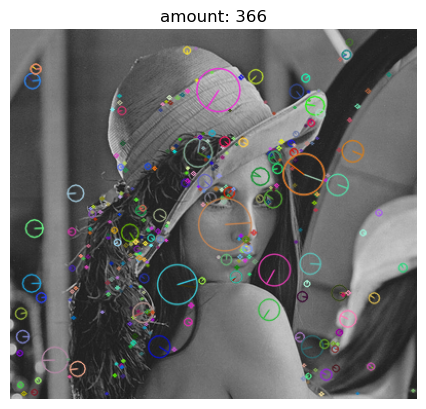

In [4]:
import cv2
import matplotlib.pyplot as plt

# SIFT特征点检测函数
def sift_feature_detection(image_path):
    # 读取图像
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("无法找到图像或读取失败")

    # 转换为灰度图像
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 创建SIFT检测器
    sift = cv2.SIFT_create()

    # 检测关键点和描述符
    keypoints, descriptors = sift.detectAndCompute(gray, None)

    # 在图像上绘制关键点
    img_with_keypoints = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    return img_with_keypoints, keypoints

# 示例用法
image_path = '1.png'
result_img, keypoints = sift_feature_detection(image_path)

# 显示结果
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title(f'amount: {len(keypoints)}')
plt.axis('off')
plt.show()